# Color 01 - Palette foundation (Solution)

Muc tieu: map dung loai du lieu vao loai color scale.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data" / "gapminder.csv").exists():
            return p
    raise FileNotFoundError("Cannot locate data/gapminder.csv")

root = resolve_repo_root()
sns.set_theme(style="whitegrid")
df = pd.read_csv(root / "data" / "gapminder.csv")
d2007 = df[df["year"] == 2007].copy()
d2007.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32


## 1) Categorical palette cho bien nominal (`continent`)

Chart phu hop: so sanh giua cac nhom roi rac (khong co thu tu tu nhien).
Mau co vai tro **phan biet nhom** (khong truyen tai magnitude).

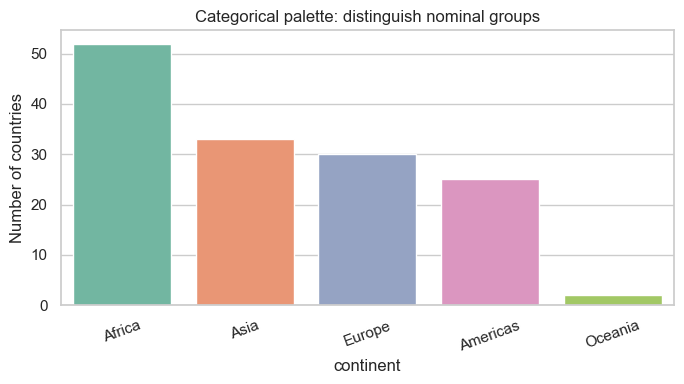

In [2]:
cat_df = (
    d2007.groupby("continent", as_index=False)
    .agg(country_count=("country", "count"))
    .sort_values("country_count", ascending=False)
)

plt.figure(figsize=(7, 4))
sns.barplot(
    data=cat_df,
    x="continent",
    y="country_count",
    hue="continent",
    palette="Set2",
    dodge=False,
    legend=False,
)
plt.title("Categorical palette: distinguish nominal groups")
plt.ylabel("Number of countries")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 2) Sequential palette cho bien lien tuc (`gdpPercap`)

Chart phu hop: heatmap/choropleth hoac bang co thu tu.
Mau co vai tro **truyen tai muc do** (light -> dark).

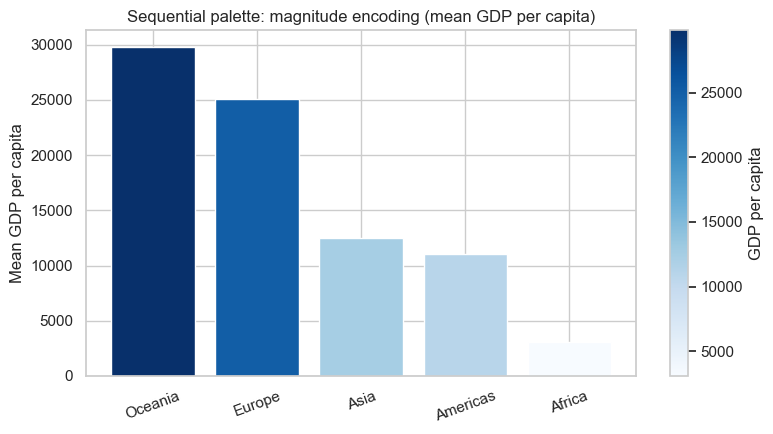

In [3]:
seq_df = (
    d2007.groupby("continent", as_index=False)
    .agg(gdp_mean=("gdpPercap", "mean"))
    .sort_values("gdp_mean", ascending=False)
)

norm = plt.Normalize(seq_df["gdp_mean"].min(), seq_df["gdp_mean"].max())
cmap = plt.cm.Blues
colors = cmap(norm(seq_df["gdp_mean"].to_numpy()))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(seq_df["continent"], seq_df["gdp_mean"], color=colors)
ax.set_title("Sequential palette: magnitude encoding (mean GDP per capita)")
ax.set_ylabel("Mean GDP per capita")
ax.tick_params(axis="x", rotation=20)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="GDP per capita")

plt.tight_layout()
plt.show()

## 3) Diverging palette khi co diem giua co y nghia (0)

Ta tao bien `lifeExp_delta` = lifeExp(country) - median(2007).
Chart phu hop: bar theo do lech dau (+/-) quanh moc trung tam.

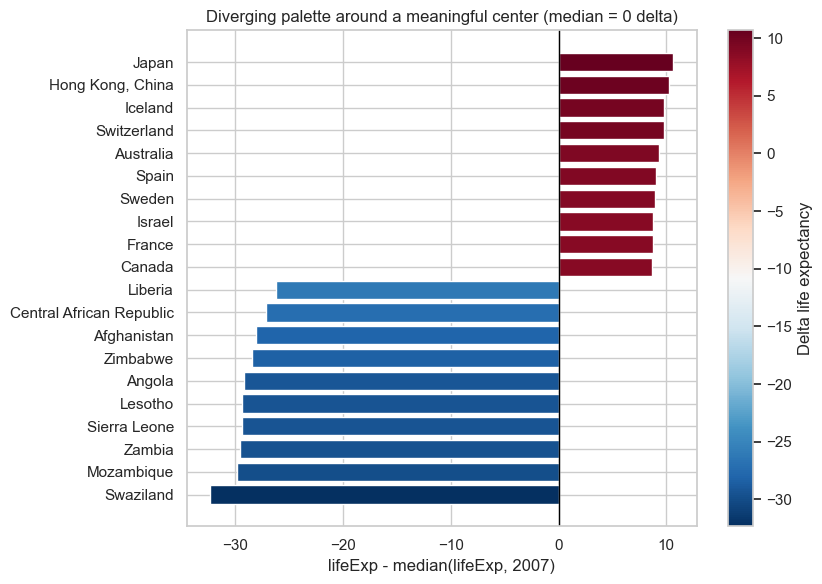

In [4]:
med = d2007["lifeExp"].median()
d2007["lifeExp_delta"] = d2007["lifeExp"] - med

focus = pd.concat(
    [d2007.nsmallest(10, "lifeExp_delta"), d2007.nlargest(10, "lifeExp_delta")],
    ignore_index=True,
).sort_values("lifeExp_delta")

v = focus["lifeExp_delta"].to_numpy()
norm = plt.Normalize(v.min(), v.max())
cmap = plt.cm.RdBu_r
colors = cmap(norm(v))

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.barh(focus["country"], focus["lifeExp_delta"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Diverging palette around a meaningful center (median = 0 delta)")
ax.set_xlabel("lifeExp - median(lifeExp, 2007)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Delta life expectancy")

plt.tight_layout()
plt.show()

## Reflection
- Vi sao khong dung palette categorical cho bien lien tuc?
- Neu khong co moc 0/target ro rang, ban co dung diverging khong?